In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014009()
subject, session, run = 1, "session_0", "run_0"

In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.797 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


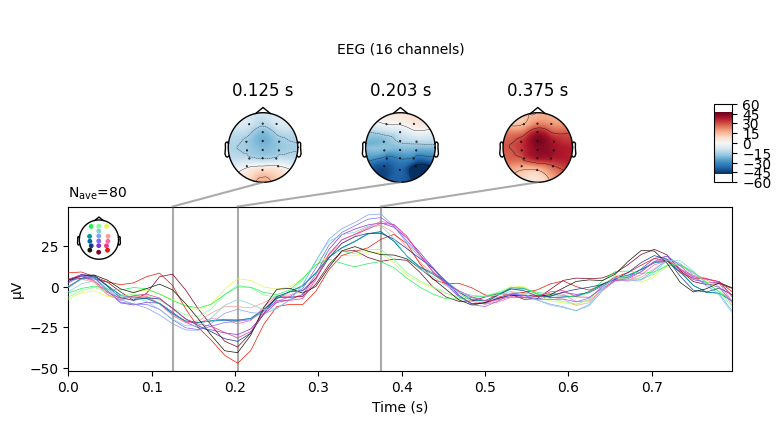

In [4]:
from mne import combine_evoked

target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
#contrast.apply_baseline((-0.2,0))
_= contrast.plot_joint()

In [5]:
#split = 100
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [6]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('numpy')



X_train = epochs_train.get_data().astype(np.float64)
y_train = labels_train
X_test = epochs_test.get_data().astype(np.float64)
y_test = labels_test

X_train.shape


(288, 16, 52)

In [82]:
import cupy
from hoda.tenalg import force_toeplitz
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from mne.decoding import Scaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

hoda_lda = Pipeline([
        ('scaler', Scaler(with_mean=True, scalings='mean')),
        ('hoda', HODA(
            rank=None,
            max_iter=256,
            tol=0,
            init ='mlsvd',
            verbose=True,
            shrinkage=('lw','lw'),
            toeplitz=(1,),
            solver='lfl',
            keep_train_info=True,
            taper=False,
            #solver_params=dict(psi=0.1),
        )),
        ('lda', LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')),


])
hoda_lda.fit(X_train,y_train)

Initializing factors...


  0%|          | 0/256 [00:00<?, ?it/s]

Fit tucker model of rank [2, 2]


Pipeline(steps=[('scaler',
                 Scaler({'info': None, 'scalings': 'mean', 'with_mean': True, 'with_std': True})),
                ('hoda',
                 HODA(keep_train_info=True, max_iter=256,
                      shrinkage=('lw', 'lw'), solver='lfl', toeplitz=(1,),
                      tol=0, verbose=True)),
                ('lda',
                 LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))])

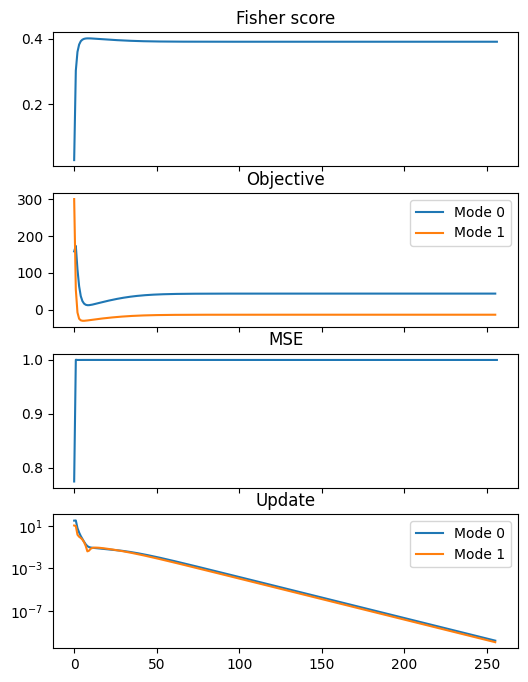

In [83]:
fig, axs = plt.subplots(4,1, sharex=True, figsize=(6,8))

axs[0].set_title('Fisher score')
axs[0].plot(hoda_lda['hoda'].train_info_["f_score"])

axs[1].set_title('Objective')
axs[1].plot(np.asarray(hoda_lda['hoda'].train_info_["mode_objective"]).T, label=['Mode 0', 'Mode 1'])
axs[1].legend()

axs[2].set_title('MSE')
axs[2].plot(hoda_lda['hoda'].train_info_["mse"])

axs[3].set_title('Update')
axs[3].semilogy(np.asarray(hoda_lda['hoda'].train_info_["mode_update"]).T, label=['Mode 0', 'Mode 1'])
axs[3].legend()

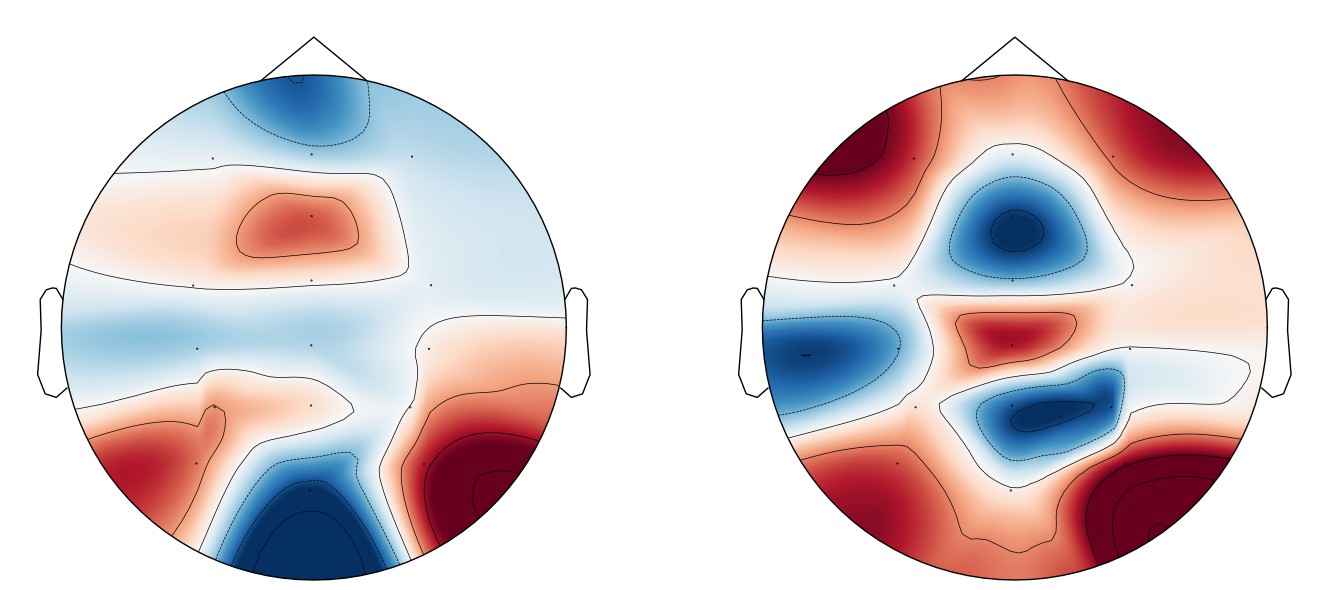

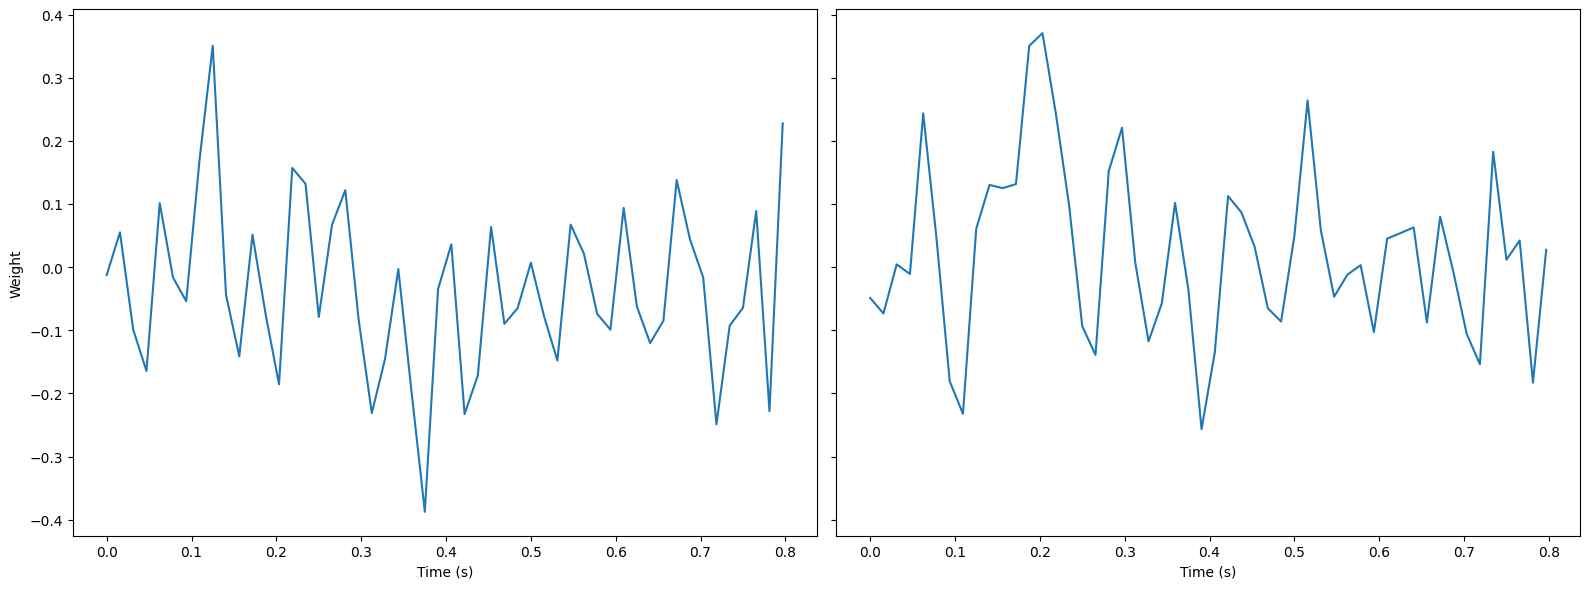

In [84]:
fig, axs = plt.subplots(1,max(hoda_lda['hoda'].rank_[0],2), figsize=(16,6), layout='tight')
for i in range(hoda_lda['hoda'].rank_[0]):
    w = cupy.asnumpy(hoda_lda['hoda'].scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)

fig, axs = plt.subplots(1,max(hoda_lda['hoda'].rank_[1],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)
for i in range(hoda_lda['hoda'].rank_[1]):
    w = cupy.asnumpy(hoda_lda['hoda'].scalings_[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].sharey(axs[0])
axs[0].set_ylabel('Weight');


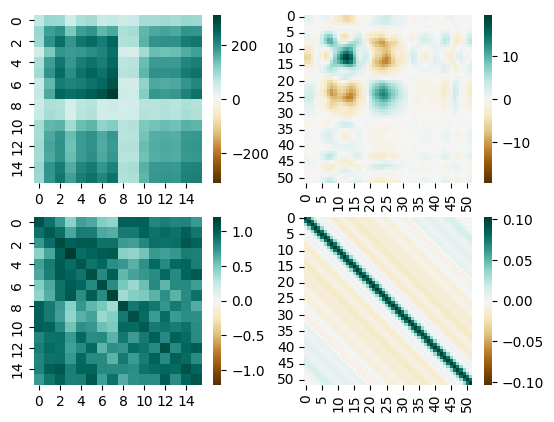

In [85]:
_, axs = plt.subplots(2,2)
for k in range(2):
    scatter_b = cupy.asnumpy(hoda_lda['hoda'].scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[0,k].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[0,k])    
    scatter_w = cupy.asnumpy(hoda_lda['hoda'].scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[1,k])    
    axs[1,k].set_aspect('equal')

In [86]:
Xt_train = cupy.asnumpy(hoda_lda['hoda'].transform(X_train))
Xt_test = cupy.asnumpy(hoda_lda['hoda'].transform(X_test))

<AxesSubplot: >

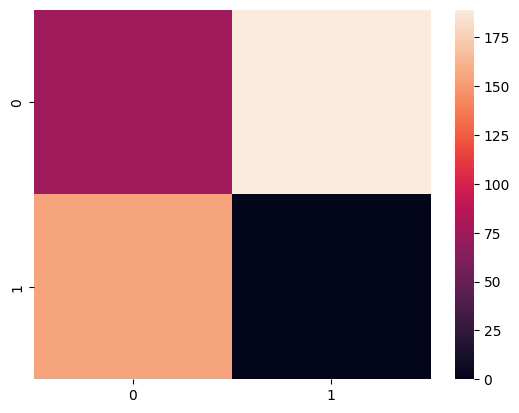

In [87]:
import scipy.stats
import seaborn as sns
train_score_tensor = cupy.asnumpy(hoda_lda['hoda']._transform(tl.tensor(X_train)))

samples = []
for c in hoda_lda['hoda'].classes_:
    samples.append(train_score_tensor[y_train==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
sns.heatmap(F,vmin=0)


<AxesSubplot: >

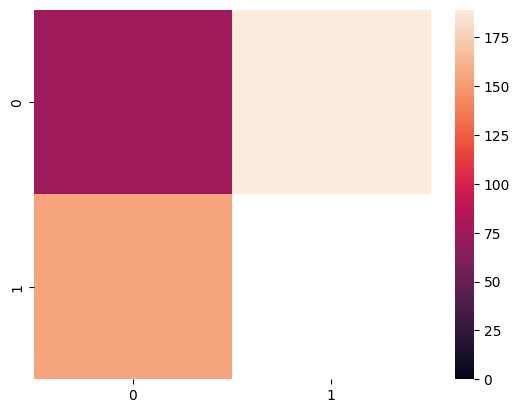

In [88]:
sns.heatmap(F, mask=p>0.05,vmin=0)


In [89]:
"""
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2)
Xt_tsne_train = tsne.fit_transform(Xt_train)
plt.scatter(Xt_tsne_train[y_train=='NonTarget'][:,0],Xt_tsne_train[y_train=='NonTarget'][:,1])
plt.scatter(Xt_tsne_train[y_train=='Target'][:,0],Xt_tsne_train[y_train=='Target'][:,1])
"""

"\nfrom sklearn.manifold import TSNE\ntsne = TSNE(n_components=2)\nXt_tsne_train = tsne.fit_transform(Xt_train)\nplt.scatter(Xt_tsne_train[y_train=='NonTarget'][:,0],Xt_tsne_train[y_train=='NonTarget'][:,1])\nplt.scatter(Xt_tsne_train[y_train=='Target'][:,0],Xt_tsne_train[y_train=='Target'][:,1])\n"

<AxesSubplot: xlabel='score', ylabel='Count'>

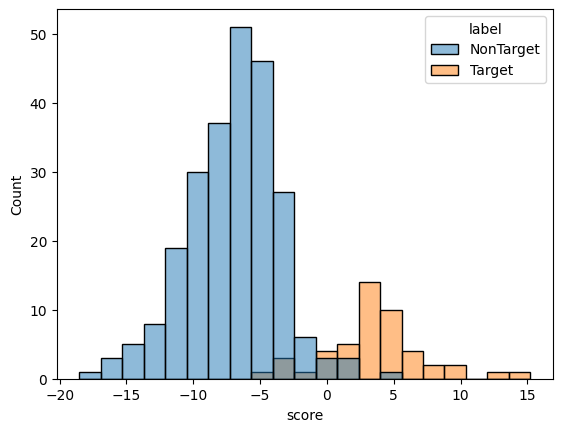

In [90]:
import pandas as pd

train_scores = cupy.asnumpy(hoda_lda.decision_function(X_train))
df = pd.DataFrame(dict(score=cupy.asnumpy(train_scores),label=labels_train))
sns.histplot(data=df, x='score', hue='label')

In [91]:
roc_auc_score(y_train,train_scores)

0.9826388888888888

<AxesSubplot: xlabel='score', ylabel='Count'>

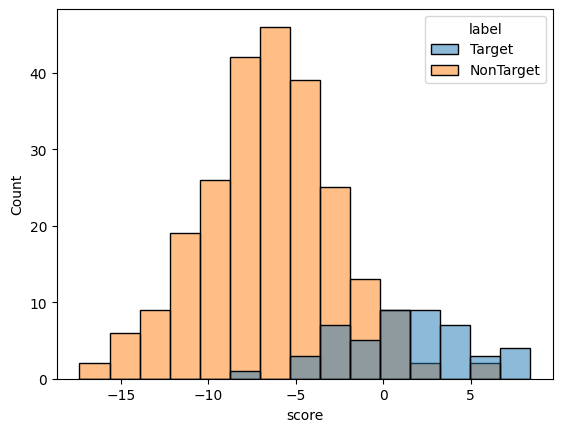

In [92]:
import pandas as pd

test_scores = cupy.asnumpy(hoda_lda.decision_function(X_test))
df = pd.DataFrame(dict(score=cupy.asnumpy(test_scores),label=labels_test))
sns.histplot(data=df, x='score', hue='label')

In [93]:
roc_auc_score(y_test,test_scores)

0.9315972222222222